# Calibración de Umbral y Curvas ROC/PR

Evalúa los tres modelos sobre el test set completo y determina el umbral operativo óptimo.

In [14]:
import sys, subprocess
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
    'torch', 'torchvision', 'timm', 'albumentations',
    'matplotlib', 'opencv-python', 'pandas', 'scikit-learn', 'tqdm'])

0

In [15]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (
    roc_curve, auc, precision_recall_curve,
    f1_score, precision_score, recall_score,
    average_precision_score
)
from tqdm import tqdm

from src.config import make_config, FAKE_CLASSES, MODEL_COLORS, COLOR_REAL, COLOR_FAKE
from src.data import build_frame_dataframe, get_transforms
from src.models import XceptionBiFPN, XceptionFNO, build_model, load_model

In [16]:
BASE_DIR = Path.home() / 'TPF-VA'
CONFIG = make_config(
DATA_DIR       = BASE_DIR / 'dataset_split',
    OUTPUT_DIR     = BASE_DIR / 'outputs/analisis',
    CKPT_BASELINE  = BASE_DIR / 'outputs/best_xception.pth',
    CKPT_BIFPN     = '/home/mariasarachaga/outputs/xception_bifpn/best_xception_bifpn.pth',
    CKPT_FNO       = BASE_DIR / 'outputs/xception_fno/best_xception_fno.pth',
    BIFPN_CHANNELS = 256,
    BIFPN_LAYERS   = 2,
    FNO_CHANNELS   = 32,
    FNO_MODES      = 8,
    FNO_BLOCKS     = 4,
)
DEVICE = CONFIG['DEVICE']

print('Config lista.')

Config lista.


In [17]:
baseline = build_model('xception', DEVICE)
baseline, auc_b, _ = load_model(baseline, CONFIG['CKPT_BASELINE'], DEVICE)
print(f'Baseline  val AUC: {auc_b:.4f}')

model_bifpn = XceptionBiFPN(CONFIG['DROPOUT'], CONFIG['BIFPN_CHANNELS'], CONFIG['BIFPN_LAYERS'])
model_bifpn, auc_bifpn, _ = load_model(model_bifpn, CONFIG['CKPT_BIFPN'], DEVICE)
print(f'BiFPN     val AUC: {auc_bifpn:.4f}')

model_fno = XceptionFNO(CONFIG['DROPOUT'], CONFIG['FNO_CHANNELS'], CONFIG['FNO_MODES'], CONFIG['FNO_BLOCKS'])
model_fno, auc_fno, _ = load_model(model_fno, CONFIG['CKPT_FNO'], DEVICE)
print(f'FNO       val AUC: {auc_fno:.4f}')

MODELS = {'Baseline': baseline, 'BiFPN': model_bifpn, 'FNO': model_fno}

/home/mariasarachaga/.local/lib/python3.10/site-packages/timm/models/_factory.py:138: UserWarning: Mapping deprecated model name xception to current legacy_xception.
  model = create_fn(


xception — parámetros entrenables: 20,809,001
Baseline  val AUC: 0.8222
BiFPN     val AUC: 0.8180
FNO       val AUC: 0.8178


In [18]:
class DeepfakeDatasetWithMeta(Dataset):
    """Variante de DeepfakeDataset que además devuelve method y path,
    necesarios para el CSV de inferencia completo."""
    def __init__(self, df, transforms):
        self.df = df.reset_index(drop=True)
        self.transforms = transforms
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = np.array(Image.open(row['path']).convert('RGB'))
        tensor = self.transforms(image=img)['image']
        return tensor, row['label'], row['method'], row['path']

_, transforms = get_transforms(CONFIG['IMG_SIZE'])
test_df = build_frame_dataframe(CONFIG['DATA_DIR'], splits=['test'])
print(f'Test set: {len(test_df):,} frames')
print(test_df.groupby(['method','label']).size().to_string())

loader = DataLoader(
    DeepfakeDatasetWithMeta(test_df, transforms),
    batch_size=CONFIG['BATCH_SIZE'],
    num_workers=CONFIG['NUM_WORKERS'],
    shuffle=False, pin_memory=True
)

Test set: 8,401 frames
method          label
Deepfakes       1        1400
Face2Face       1        1400
FaceShifter     1        1400
FaceSwap        1        1401
NeuralTextures  1        1400
real            0        1400


## Inferencia completa

Corre los tres modelos sobre todo el test set y guarda las probabilidades en un CSV.

In [19]:
CSV_PATH = CONFIG['OUTPUT_DIR'] / 'predictions.csv'

if CSV_PATH.exists():
    print(f'predictions.csv ya existe, cargando desde disco...')
    pred_df = pd.read_csv(CSV_PATH)
else:
    all_labels, all_methods, all_paths = [], [], []
    all_probs = {name: [] for name in MODELS}

    with torch.no_grad():
        for batch in tqdm(loader, desc='Inferencia'):
            tensors, labels, methods, paths = batch
            tensors = tensors.to(DEVICE)
            all_labels.extend(labels.numpy().tolist())
            all_methods.extend(list(methods))
            all_paths.extend(list(paths))
            for name, model in MODELS.items():
                probs = torch.sigmoid(model(tensors)).cpu().numpy().tolist()
                all_probs[name].extend(probs)

    pred_df = pd.DataFrame({
        'path'   : all_paths,
        'label'  : all_labels,
        'method' : all_methods,
        'prob_Baseline': all_probs['Baseline'],
        'prob_BiFPN'   : all_probs['BiFPN'],
        'prob_FNO'     : all_probs['FNO'],
    })
    pred_df.to_csv(CSV_PATH, index=False)
    print(f'Guardado: {CSV_PATH}')

print(pred_df.head())
print(f'\nTotal: {len(pred_df):,} filas')

predictions.csv ya existe, cargando desde disco...
                                                path  label    method  \
0  /home/mariasarachaga/TPF-VA/dataset_split/test...      1  FaceSwap   
1  /home/mariasarachaga/TPF-VA/dataset_split/test...      1  FaceSwap   
2  /home/mariasarachaga/TPF-VA/dataset_split/test...      1  FaceSwap   
3  /home/mariasarachaga/TPF-VA/dataset_split/test...      1  FaceSwap   
4  /home/mariasarachaga/TPF-VA/dataset_split/test...      1  FaceSwap   

           prob_Baseline            prob_BiFPN               prob_FNO  
0    [0.999990701675415]  [0.9999618530273438]   [0.9999990463256836]  
1   [0.9914214015007019]  [0.9982326030731201]   [0.9934344291687012]  
2    [0.999538779258728]  [0.9998416900634766]   [0.9999977350234985]  
3   [0.9963471293449402]   [0.994978129863739]   [0.9998477697372437]  
4  [0.45606541633605957]  [0.9888625741004944]  [0.11445626616477966]  

Total: 8,401 filas


## Curvas ROC con umbral óptimo (Youden)

El **índice de Youden** maximiza `sensibilidad + especificidad - 1`, equivalente a maximizar la distancia vertical a la diagonal aleatoria. Es el umbral que balancea mejor TPR y FPR.

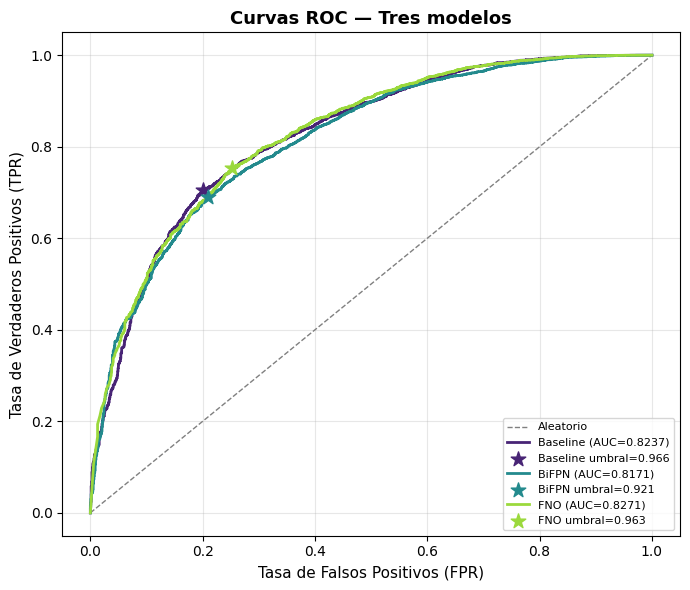

Umbrales Youden óptimos:
  Baseline: 0.9659
  BiFPN: 0.9207
  FNO: 0.9633


In [20]:
y_true = np.array(pred_df['label'].tolist()).flatten()

prob_cols = {'Baseline': 'prob_Baseline', 'BiFPN': 'prob_BiFPN', 'FNO': 'prob_FNO'}

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0,1],[0,1],'--', color='gray', lw=1, label='Aleatorio')

youden_thresholds = {}

for name, col in prob_cols.items():
    y_score = pred_df[col].astype(str).str.replace('[', '', regex=False).str.replace(']', '', regex=False).astype(float).values.flatten()
    y_true_numeric = y_true.astype(int)
    fpr, tpr, thresholds = roc_curve(y_true_numeric, y_score)
    roc_auc = auc(fpr, tpr)

    youden_idx = np.argmax(tpr - fpr)
    opt_thr = thresholds[youden_idx]
    opt_fpr = fpr[youden_idx]
    opt_tpr = tpr[youden_idx]
    youden_thresholds[name] = opt_thr

    color = MODEL_COLORS[name]
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f'{name} (AUC={roc_auc:.4f})')
    ax.scatter(opt_fpr, opt_tpr, s=120, color=color,
               zorder=5, marker='*',
               label=f'{name} umbral={opt_thr:.3f}')

ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=11)
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=11)
ax.set_title('Curvas ROC — Tres modelos', fontsize=13, fontweight='bold')
ax.legend(fontsize=8, loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()

CONFIG['OUTPUT_DIR'].mkdir(parents=True, exist_ok=True)
plt.savefig(CONFIG['OUTPUT_DIR'] / 'roc_curves.png', dpi=150)
plt.show()

print('Umbrales Youden óptimos:')
for k, v in youden_thresholds.items():
    print(f'  {k}: {v:.4f}')

## Curvas Precision-Recall con umbral óptimo (F1 máximo)

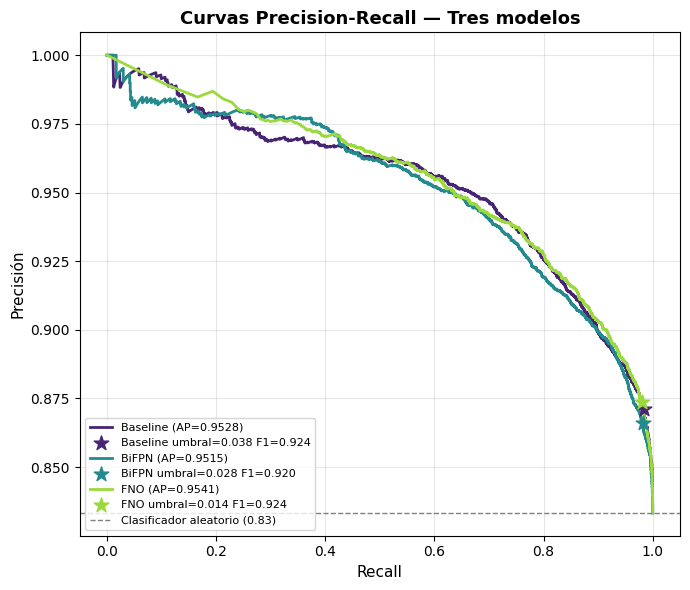

Umbrales F1-óptimo:
  Baseline: 0.0375
  BiFPN: 0.0283
  FNO: 0.0141


In [21]:
fig, ax = plt.subplots(figsize=(7, 6))

f1_thresholds = {}

for name, col in prob_cols.items():
    y_score = pred_df[col].astype(str).str.replace('[', '', regex=False).str.replace(']', '', regex=False).astype(float).values.flatten()
    y_true_numeric = y_true.astype(int)
    precision, recall, thresholds = precision_recall_curve(y_true_numeric, y_score)
    ap = average_precision_score(y_true_numeric, y_score)
    f1_scores = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-9)
    best_idx  = np.argmax(f1_scores)
    opt_thr   = thresholds[best_idx]
    f1_thresholds[name] = opt_thr

    color = MODEL_COLORS[name]
    ax.plot(recall, precision, color=color, lw=2,
            label=f'{name} (AP={ap:.4f})')
    ax.scatter(recall[best_idx], precision[best_idx], s=120, color=color,
               zorder=5, marker='*',
               label=f'{name} umbral={opt_thr:.3f} F1={f1_scores[best_idx]:.3f}')

baseline_rate = y_true.mean()
ax.axhline(baseline_rate, color='gray', lw=1, linestyle='--',
           label=f'Clasificador aleatorio ({baseline_rate:.2f})')
ax.set_xlabel('Recall', fontsize=11)
ax.set_ylabel('Precisión', fontsize=11)
ax.set_title('Curvas Precision-Recall — Tres modelos', fontsize=13, fontweight='bold')
ax.legend(fontsize=8, loc='lower left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(CONFIG['OUTPUT_DIR'] / 'pr_curves.png', dpi=150)
plt.show()

print('Umbrales F1-óptimo:')
for k, v in f1_thresholds.items():
    print(f'  {k}: {v:.4f}')

In [22]:
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'jinja2'])

0

## Tabla de métricas en umbral óptimo

In [23]:
from sklearn.metrics import confusion_matrix

rows_m = []
for name, col in prob_cols.items():
    y_score = pred_df[col].astype(str).str.replace('[', '', regex=False).str.replace(']', '', regex=False).astype(float).values.flatten()

    for thr_type, thr_dict in [('Youden', youden_thresholds), ('F1-max', f1_thresholds)]:
        thr = thr_dict[name]
        y_pred = (y_score >= thr).astype(int)

        tn, fp, fn, tp = confusion_matrix(y_true.astype(int), y_pred).ravel()
        fpr_val = fp / (fp + tn)

        rows_m.append({
            'Modelo'    : name,
            'Umbral'    : thr_type,
            'Threshold' : round(float(thr), 4),
            'F1'        : round(f1_score(y_true.astype(int), y_pred), 4),
            'Precisión' : round(precision_score(y_true.astype(int), y_pred), 4),
            'Recall'    : round(recall_score(y_true.astype(int), y_pred), 4),
            'Acc'       : round((y_pred == y_true.astype(int)).mean(), 4),
            'FNR'       : round(1 - recall_score(y_true.astype(int), y_pred), 4),
            'FPR'       : round(fpr_val, 4),
        })

metrics_df = pd.DataFrame(rows_m)
metrics_df.to_csv(CONFIG['OUTPUT_DIR'] / 'metrics_por_umbral.csv', index=False)
print(metrics_df.to_string(index=False))

  Modelo Umbral  Threshold     F1  Precisión  Recall    Acc    FNR    FPR
Baseline Youden     0.9659 0.8084     0.9460  0.7058 0.7212 0.2942 0.2014
Baseline F1-max     0.0375 0.9241     0.8713  0.9837 0.8654 0.0163 0.7264
   BiFPN Youden     0.9207 0.7966     0.9428  0.6896 0.7065 0.3104 0.2093
   BiFPN F1-max     0.0283 0.9202     0.8661  0.9814 0.8581 0.0186 0.7586
     FNO Youden     0.9633 0.8357     0.9373  0.7539 0.7529 0.2461 0.2521
     FNO F1-max     0.0141 0.9236     0.8737  0.9796 0.8650 0.0204 0.7079


## Distribución de probabilidades por clase

Un modelo bien calibrado debería mostrar dos picos separados: uno cerca de 0 (reales) y otro cerca de 1 (fakes). La superposición entre picos indica la zona de incertidumbre donde el umbral importa más.

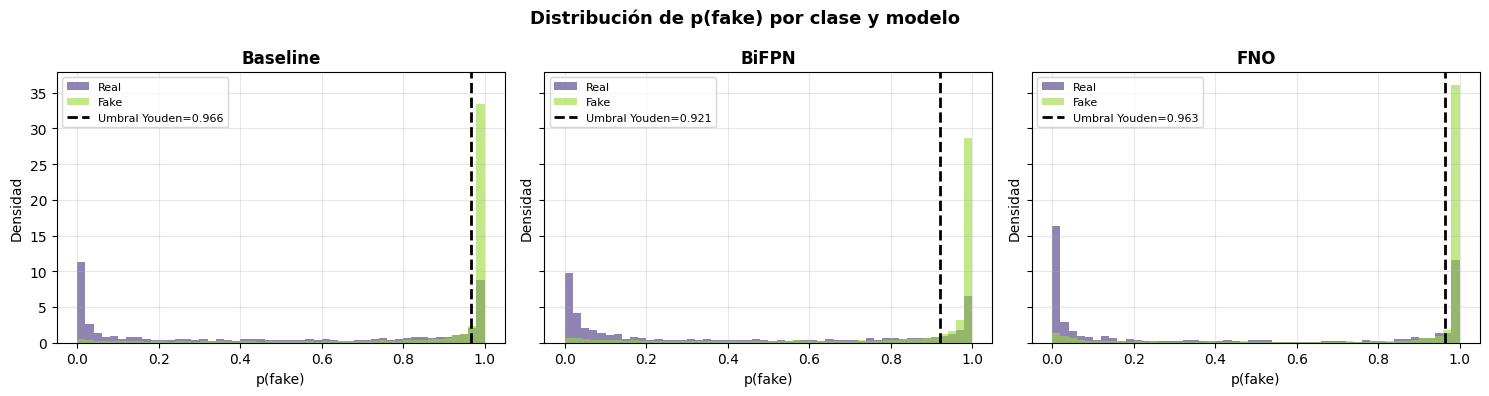

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
fig.suptitle('Distribución de p(fake) por clase y modelo', fontsize=13, fontweight='bold')

for ax, (name, col) in zip(axes, prob_cols.items()):
    probs_col = pred_df[col].astype(str).str.replace('[', '', regex=False).str.replace(']', '', regex=False).astype(float)
    probs_real = probs_col[pred_df['label'] == 0].values.flatten()
    probs_fake = probs_col[pred_df['label'] == 1].values.flatten()
    
    opt_thr = youden_thresholds[name]

    ax.hist(probs_real, bins=50, alpha=0.6, color=COLOR_REAL, label='Real', density=True)
    ax.hist(probs_fake, bins=50, alpha=0.6, color=COLOR_FAKE, label='Fake', density=True)
    ax.axvline(opt_thr, color='black', lw=2, linestyle='--',
               label=f'Umbral Youden={opt_thr:.3f}')
    
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('p(fake)')
    ax.set_ylabel('Densidad')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(CONFIG['OUTPUT_DIR'] / 'prob_distributions.png', dpi=150)
plt.show()

## Resumen

In [25]:
best = metrics_df[metrics_df['Umbral']=='Youden'].sort_values('F1', ascending=False)
for _, r in best.iterrows():
    print(f"  {r['Modelo']:10s} | umbral={r['Threshold']:.3f} | "
          f"F1={r['F1']:.4f} | Recall={r['Recall']:.4f} | FNR={r['FNR']:.4f}")
print()
print('Archivos generados:')
for f in sorted(CONFIG['OUTPUT_DIR'].glob('*')):
    print(f'  {f.name}')

  FNO        | umbral=0.963 | F1=0.8357 | Recall=0.7539 | FNR=0.2461
  Baseline   | umbral=0.966 | F1=0.8084 | Recall=0.7058 | FNR=0.2942
  BiFPN      | umbral=0.921 | F1=0.7966 | Recall=0.6896 | FNR=0.3104

Archivos generados:
  confusion_matrices.png
  fn_consensus_—_los_3_modelos_fallan_(1298_casos).png
  fn_—_fno_—_deepfakes_(p_más_baja_primero).png
  fn_—_fno_—_face2face_(p_más_baja_primero).png
  fn_—_fno_—_faceshifter_(p_más_baja_primero).png
  fn_—_fno_—_faceswap_(p_más_baja_primero).png
  fn_—_fno_—_neuraltextures_(p_más_baja_primero).png
  fnr_por_metodo.csv
  fnr_por_metodo.png
  fp_consensus_—_reales_que_todos_confunden_(173_casos).png
  fp_—_fno_—_reales_clasificados_como_fake_(p_más_alta_primero.png
  metricas_por_metodo.csv
  metrics_por_umbral.csv
  pr_curves.png
  predictions.csv
  prob_distributions.png
  prob_por_metodo.png
  roc_curves.png
